In [1]:
run_batchprocess = True

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os,glob
import re
import sys
sys.path.append('/root/capsule/code/')
from pprint import pprint 
from prepare_img_utils import *
from utils import get_paths

import scanpy as sc
import anndata as ad
import scvi
from registerCCF_util import *

def get_record(s):
    return {
        'filename':s.get('filename'),
        'height': s.get('height'),
        'width': s.get('width'), 
        'ox': s.get('anchoring')[0], 
        'oy': s.get('anchoring')[1],
        'oz': s.get('anchoring')[2],
        'ux': s.get('anchoring')[3],
        'uy': s.get('anchoring')[4],
        'uz': s.get('anchoring')[5], 
        'vx': s.get('anchoring')[6], 
        'vy': s.get('anchoring')[7],
        'vz': s.get('anchoring')[8],
    }

# HOMEDIR = '/root/capsule//'
# paths = get_paths()
# print(paths.keys())

In [3]:
paths = get_paths()
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'registered_scratch': PosixPath('/root/capsule/scratch/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [4]:
paths['data_root']

PosixPath('/root/capsule/data')

In [5]:
scaling_factor=1/32; 
# all_file_path = paths['data_root'] /'image_xml/*.jpg'
all_file_path = os.path.join(paths['data_root'],'Nardone_2024_merfish_processing','image_xml', '*.jpg')
for f in glob.glob(all_file_path):
    print(os.path.basename(f).split('cell_img_')[1].split('.')[0])   # btw these images are 25um resolutions

MouseZM_ZM0
MouseF_F2
MouseZM_ZM7p1
MouseZM_ZM4
MouseEg_Eg2
MouseC_C4
MouseZM_ZM2
MouseF_F4
MouseC_C2
MouseZM_ZM5p1
MouseEg_Eg4
MouseZM_ZM1
MouseF_F3
MouseZM_ZM7p2
MouseEg_Eg3
MouseC_C5
MouseEg_B3
MouseZM_ZM3
MouseEg_Eg1
MouseC_C3
MouseZM_ZM6p1
MouseZM_ZM5p2
MouseEg_Eg5
MouseF_F1


In [6]:
all_file_path

'/root/capsule/data/Nardone_2024_merfish_processing/image_xml/*.jpg'

In [7]:
slicename_all = [os.path.basename(f).split('cell_img_')[1].split('.')[0] for f in glob.glob(all_file_path)]
slicename_all.sort()
print(slicename_all, len(slicename_all))

['MouseC_C2', 'MouseC_C3', 'MouseC_C4', 'MouseC_C5', 'MouseEg_B3', 'MouseEg_Eg1', 'MouseEg_Eg2', 'MouseEg_Eg3', 'MouseEg_Eg4', 'MouseEg_Eg5', 'MouseF_F1', 'MouseF_F2', 'MouseF_F3', 'MouseF_F4', 'MouseZM_ZM0', 'MouseZM_ZM1', 'MouseZM_ZM2', 'MouseZM_ZM3', 'MouseZM_ZM4', 'MouseZM_ZM5p1', 'MouseZM_ZM5p2', 'MouseZM_ZM6p1', 'MouseZM_ZM7p1', 'MouseZM_ZM7p2'] 24


In [8]:
len(slicename_all)

24

# batch process

In [9]:
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'registered_scratch': PosixPath('/root/capsule/scratch/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [10]:
run_batchprocess

True

In [11]:
HOMEDIR = str(paths['data_root'] / 'Nardone_2024_merfish_processing' )

In [12]:
HOMEDIR

'/root/capsule/data/Nardone_2024_merfish_processing'

In [13]:

from PIL import Image
if run_batchprocess:
    slicenum = ['1']
    slicenum=[int(i) for i in slicenum]

    registered_output = paths['registered_scratch']
    os.makedirs(registered_output, exist_ok=True)

    for name_of_slice in slicename_all:
        image_files=glob.glob(HOMEDIR + f'/image_xml/*{name_of_slice}.jpg')
        # load your file
        flat_name=[]  
        for i in image_files:
            result=re.search('(.*).jpg', i)
            n=result.group(1)+('_nl.flat')
            flat_name+=[n]
        assert(len(image_files)==1)
        with Image.open(image_files[0]) as im:
            w, h = im.size
        json_name=image_files 
        d = {'slicenum': slicenum, 'json_name': json_name,'flat_name':flat_name}
        name_df=pd.DataFrame(data=d)
        neurons=pd.read_csv(HOMEDIR+f'/filt_neurons_all/filt_neurons_{name_of_slice}.csv')
        neurons=neurons[neurons['slice'].isin(slicenum)]
        Max=neurons['x'].max()
        Min=neurons['y'].max()
        neurons['rescale_x']=neurons['x']*scaling_factor
        neurons['rescale_y']=neurons['y']*scaling_factor
        neurons['rescale_x'] = neurons['rescale_x'].astype(float)+500 # this was accounting for the padding that we created for the image
        neurons['rescale_y'] = neurons['rescale_y'].astype(float)+500

        # load visualign results 
        with open(HOMEDIR+f'/visualign_rez/{name_of_slice}.json') as f:
            vafile=json.load(f)
        details={s.get('filename'):s for s in vafile['slices']}
        assert(name_of_slice in list(details.keys())[0])

        rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
        neurons[['adjusted_x', 'adjusted_y']]= rez
        neurons_nl=neurons.copy()
        neurons_nl['clustid'] =neurons_nl['clustid'].astype(str)

        # load quickniii results 
        f = open(HOMEDIR+f'/quicknii_rez/quicknii_{name_of_slice}.json','r')
        data=json.loads(f.read())
        anchor=pd.DataFrame.from_records([get_record(s) for s in data['slices']])
        f.close()

        vox_dfs = []
        for slice_num, df in neurons_nl.groupby('slice'):
            quicknii_cord = get_quicknii_cord(slice_num, df,name_df,anchor,h,w) # Height and Width of image file
            vox_cord = get_vox_cord(quicknii_cord)
            vox_dfs += [vox_cord]    
        vox_df = pd.concat(vox_dfs)

        vox_df.to_csv(os.path.join(registered_output, f'registered_{name_of_slice}.csv'), index=False)
else:
    print('skip the batch process!')

/tmp/ipykernel_35843/3144589573.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
/tmp/ipykernel_35843/3144589573.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=

In [ ]:
paths['registered_scratch']

#  now pull all these together 

In [ ]:
paths['registered_scratch']

In [16]:
reg_file_path = str(paths['registered_scratch']) +'/'
pprint(glob.glob(reg_file_path+'*'))

['/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_B3.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM3.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseC_C3.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg1.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM5p2.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM6p1.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseF_F1.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg5.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseC_C5.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg3.csv',
 '/root/capsule/scratch/Nardone_2024_merfis

In [17]:
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'registered_scratch': PosixPath('/root/capsule/scratch/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [18]:
slicename_all

['MouseC_C2',
 'MouseC_C3',
 'MouseC_C4',
 'MouseC_C5',
 'MouseEg_B3',
 'MouseEg_Eg1',
 'MouseEg_Eg2',
 'MouseEg_Eg3',
 'MouseEg_Eg4',
 'MouseEg_Eg5',
 'MouseF_F1',
 'MouseF_F2',
 'MouseF_F3',
 'MouseF_F4',
 'MouseZM_ZM0',
 'MouseZM_ZM1',
 'MouseZM_ZM2',
 'MouseZM_ZM3',
 'MouseZM_ZM4',
 'MouseZM_ZM5p1',
 'MouseZM_ZM5p2',
 'MouseZM_ZM6p1',
 'MouseZM_ZM7p1',
 'MouseZM_ZM7p2']

# load all the coords + genes

In [19]:

genecounts_all = dict()
reg_points_all = dict()
for name in slicename_all:  
    
    # load re-registered CSVs from scratch; fall back to the read-only data asset if absent
    scratch_reg = os.path.join(str(paths['registered_scratch']), f'registered_{name}.csv')
    data_reg    = os.path.join(str(paths['registered_output']), f'registered_{name}.csv')
    reg_points_path = scratch_reg if os.path.exists(scratch_reg) else data_reg
    df = pd.read_csv(reg_points_path, on_bad_lines='skip')[['neuron_id','x_CCF','y_CCF','z_CCF']]    
    reg_points_all[name] = df
    
    thisdircheck = str(paths['data_root']) + '/Nardone_2024_merfish_processing/metadata/' + name + '/' + 'analyzed_data/*/region_*/'
    alltifregions = np.array([[s for s in m.split('/') if 'region' in s][0] for m in glob.glob(thisdircheck + '/images/*.tif')])
    values, counts = np.unique(alltifregions, return_counts=True)
    region_chosen = values[np.argmax(counts)]
    thisdircheck = str(paths['data_root']) + '/Nardone_2024_merfish_processing/metadata/'+ name + '/' + f'analyzed_data/*/{region_chosen}/'

    cell_loc_path = glob.glob(thisdircheck + 'cell_metadata.csv')[0]
    countmatrix_path = glob.glob(thisdircheck+'cell_by_gene.csv')[0]
    count_mtx = pd.read_csv(countmatrix_path, index_col=0).sort_index()
    genecounts_all[name] = count_mtx

In [ ]:
reg_points_path # this is where you laoded the registered results

'/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM7p2.csv'

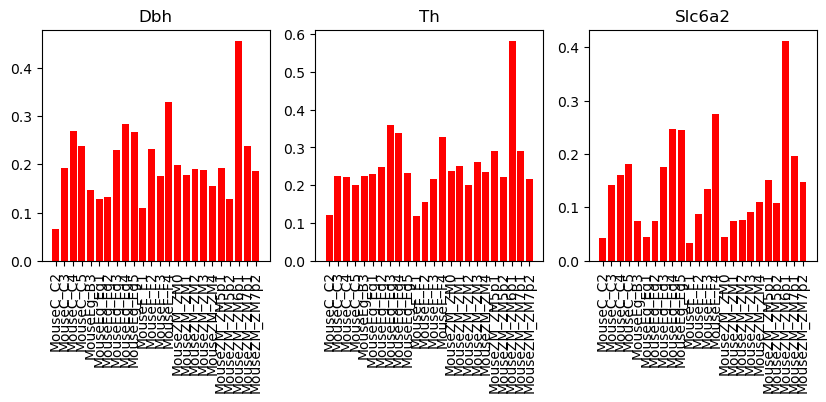

In [21]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


In [22]:
out_df_gene = []
out_df_loc = []
for p,name in enumerate(slicename_all):
    totalexpression = np.prod(np.array([genecounts_all[name][k].values for k in markergenes]), 0)
     # Boolean to indicaet if all three marker genes have to be expressed  in this cell!
    keptcellID = totalexpression>10   # if this is zero, we will have 7k cells. if this is 10 then we will have 5.4k cells
    
    # for gene counts
    foo_df = genecounts_all[name].iloc[keptcellID] 
    foo_df= foo_df.assign(slicename=list(np.repeat(name,(keptcellID).sum())))
    out_df_gene.append(foo_df)
    
    # for locations
    foo_df = reg_points_all[name].iloc[keptcellID]
    foo_df.index = foo_df['neuron_id']
    out_df_loc.append(foo_df)
    
out_df_gene = pd.concat(out_df_gene)    
out_df_loc = pd.concat(out_df_loc)    
out_df_gene.index.name = 'neuron_id'

In [23]:
df = pd.concat((out_df_loc,out_df_gene),axis=1)

In [24]:
df.shape

(5473, 390)

In [25]:
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [26]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [27]:
dictkeys = list(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'])
dictvals = list(['M', 'F', 'F', 'M']) # obtained from teh source website 
mouse_sex_map = {key: value for key, value in zip(dictkeys, dictvals)}

adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

In [28]:
markergenesid = np.array([np.where(adata_mer.var_names==m)[0][0] for m in markergenes])
totalexpression = np.prod(adata_mer.X[:,markergenesid], 1)


# Boolean to indicaet if all three marker genes have to be expre
keptcellID = totalexpression>0
adata_mer = adata_mer[keptcellID]

In [29]:
totalexpression.shape

(5473,)

In [30]:
adata_mer.shape

(5473, 315)

In [31]:
np.ptp(adata_mer.obsm['spatial']), np.ptp(adata_mer.obsm['spatial'][:,1])

(np.float64(398.07117248269503), np.float64(248.49938469664033))

# scvi and remove doublets (batch corrections)

In [32]:
scvi.settings.seed = 1
umap_random_state = 307
adata_mer = adata_mer.copy()
scvi.model.SCVI.setup_anndata(adata_mer, batch_key="slicename")
model = scvi.model.SCVI(adata_mer, n_layers=1, n_latent=4)
model.train()


INFO: Seed set to 1
INFO:lightning.fabric.utilities.seed:Seed set to 1
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottlen

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


In [33]:
adata_mer.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state, n_neighbors=30)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=1,  random_state=umap_random_state)


/tmp/ipykernel_35843/3228789248.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mer, resolution=1,  random_state=umap_random_state)


... storing 'mouse_name' as categorical
... storing 'mouse_sex' as categorical


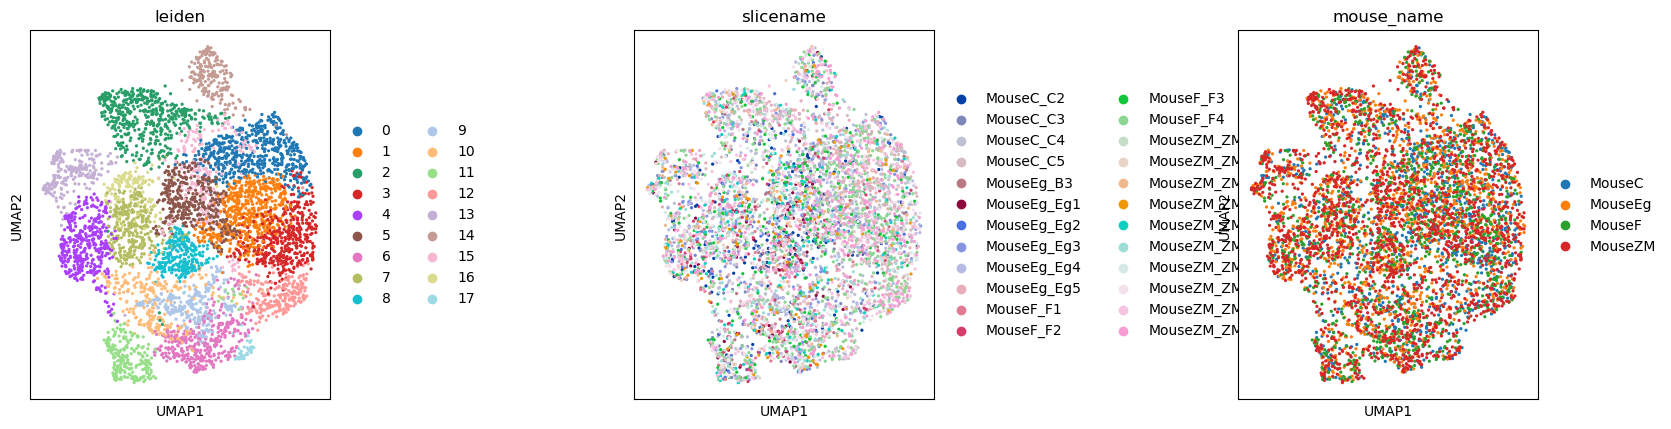

In [34]:
ax = sc.pl.umap(
    adata_mer,
    color=["leiden",'slicename','mouse_name'],show = False,
    ncols=3,
)
for a in ax:
    a.set_aspect('equal')

In [35]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

[np.str_('MouseC_C2'), np.str_('MouseC_C3'), np.str_('MouseC_C4'), np.str_('MouseC_C5'), np.str_('MouseEg_B3'), np.str_('MouseEg_Eg1'), np.str_('MouseEg_Eg2'), np.str_('MouseEg_Eg3'), np.str_('MouseEg_Eg4'), np.str_('MouseEg_Eg5'), np.str_('MouseF_F1'), np.str_('MouseF_F2'), np.str_('MouseF_F3'), np.str_('MouseF_F4'), np.str_('MouseZM_ZM0'), np.str_('MouseZM_ZM1'), np.str_('MouseZM_ZM2'), np.str_('MouseZM_ZM3'), np.str_('MouseZM_ZM4'), np.str_('MouseZM_ZM5p1'), np.str_('MouseZM_ZM5p2'), np.str_('MouseZM_ZM6p1'), np.str_('MouseZM_ZM7p1'), np.str_('MouseZM_ZM7p2')]


In [36]:
import anndata

In [37]:
X_hat_avg =model.get_normalized_expression(adata_mer, 
                                           return_numpy=False,
                                          transform_batch=all_batches,    
                                           library_size= 1)  

adata_BN = anndata.AnnData(X_hat_avg.copy())
adata_BN.obs = adata_mer.obs.copy()
adata_BN.obsm = adata_mer.obsm.copy()
adata_BN.var = adata_mer.var.copy()

cpm_scl= 1
adata_mer.layers["BN"] = X_hat_avg*cpm_scl

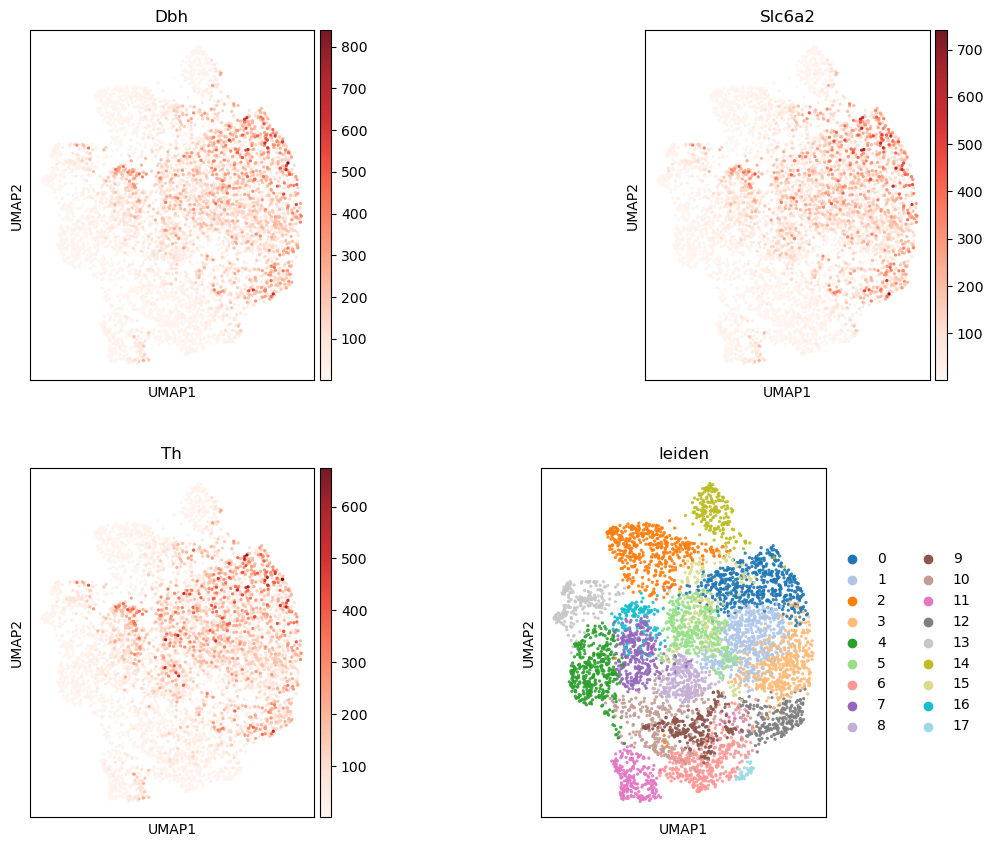

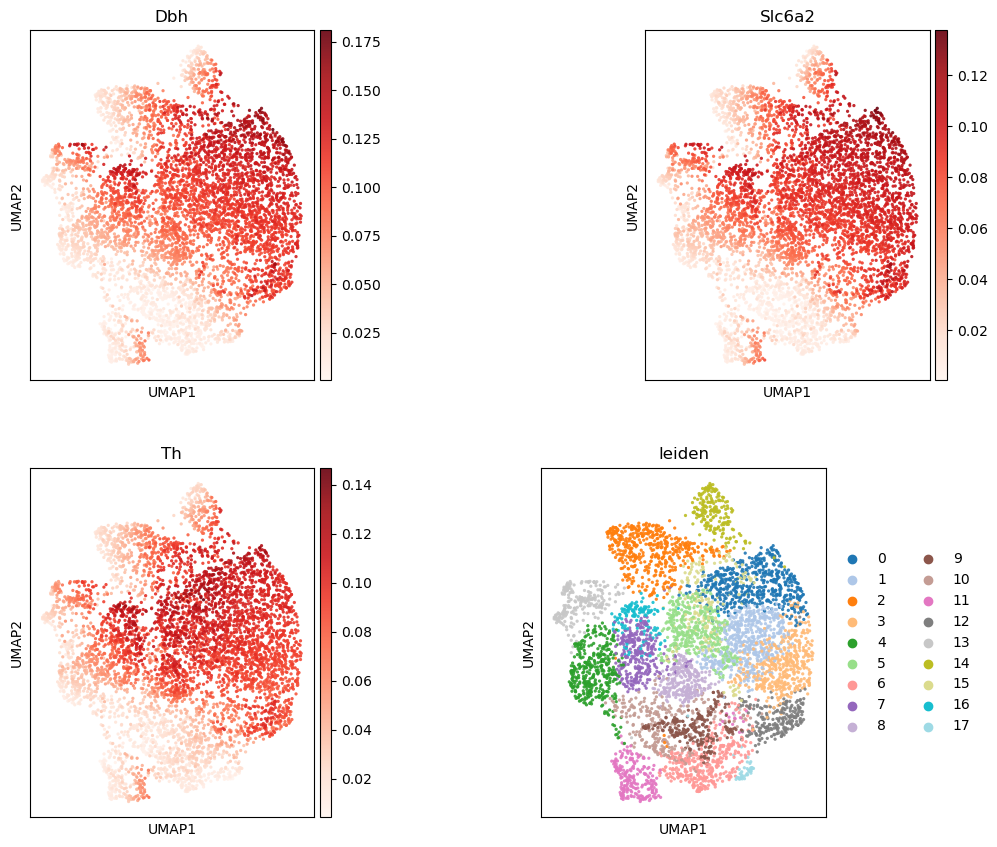

In [38]:
axes = sc.pl.umap(adata_mer, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')
    
axes = sc.pl.umap(adata_BN, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')    

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

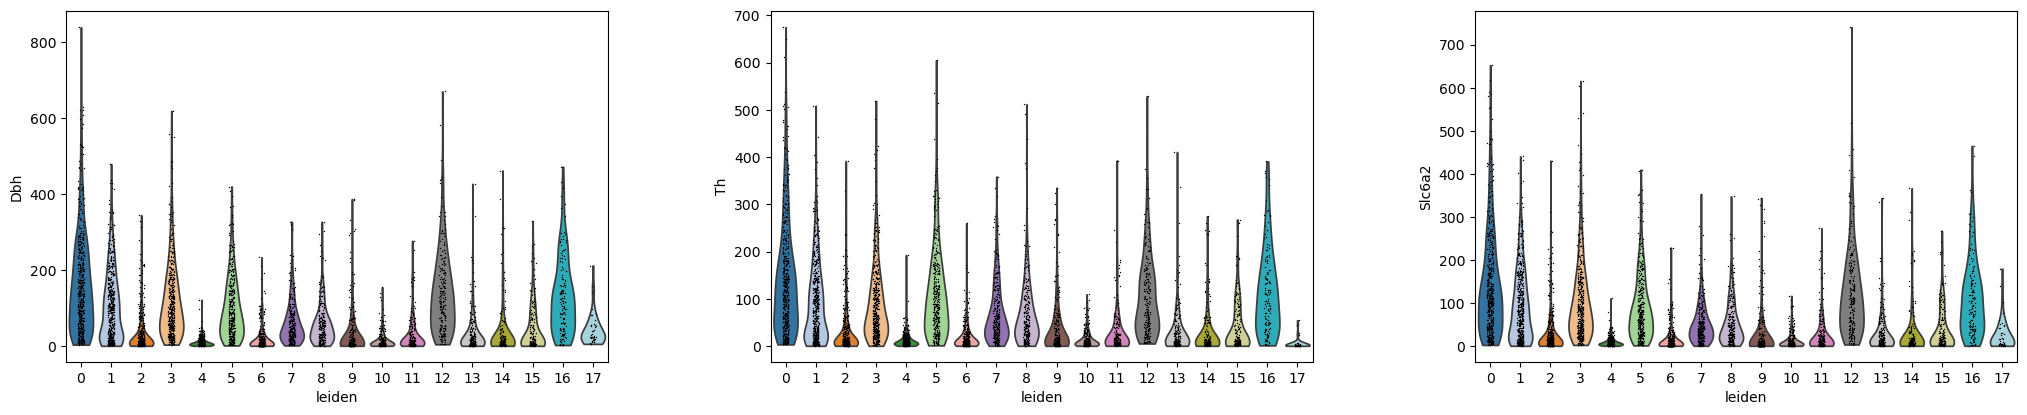

In [39]:
intersted_genes =['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']
# Check expression of known markers
sc.pl.violin(adata_mer, ['Dbh','Th','Slc6a2'], groupby='leiden')

In [40]:
libsize = np.sum(adata_mer.X)
expr = pd.DataFrame(
    1000*adata_mer[:, markergenes].X/libsize,
    columns=markergenes,
    index=adata_mer.obs_names
)
expr['leiden'] = adata_mer.obs['leiden'].values
cluster_means = expr.groupby('leiden')[markergenes].mean()
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
cluster_z

/tmp/ipykernel_35843/1932138714.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = expr.groupby('leiden')[markergenes].mean()


,Dbh,Th,Slc6a2
leiden,,,
0,2.008623,1.986171,2.007020
1,0.864604,0.785169,0.862740
2,-0.718304,-0.709541,-0.680041
3,1.108380,0.774484,1.137304
4,-1.145742,-1.095066,-1.099361
5,0.711551,1.265446,0.813442
6,-0.956452,-0.925569,-0.943814
7,-0.069244,0.282794,-0.101604
8,-0.149745,0.278447,-0.077838


In [41]:
chosen_ks = cluster_z[
    (cluster_z['Dbh'] > 0) &
    (cluster_z['Th'] > 0) &
    (cluster_z['Slc6a2'] > 0)
].index.astype(int).tolist()
chosen_ks.sort()

# ### if we want to remove the cluster 0 
# threshold = 0  # or 0.5
# chosen_ks = cluster_z[
#     (cluster_z > threshold).all(axis=1)
# ].index.astype(int).tolist()

print("Selected clusters:", chosen_ks)

Selected clusters: [0, 1, 3, 5, 12, 16]


In [42]:


mask = adata_mer.obs['leiden'].isin([str(k) for k in chosen_ks]) 
# non_mask = adata_mer.obs['leiden'].isin([str(k) for k in notchosen_ks]) 
adata_subset = adata_mer[mask].copy() 
print(f"Original size: {adata_mer.n_obs} cells")
print(f"Subset size: {adata_subset.n_obs} cells")
leidenmaskthingy = np.array(adata_subset.obs['leiden'].copy())

Original size: 5473 cells
Subset size: 2255 cells


# visualize them 

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

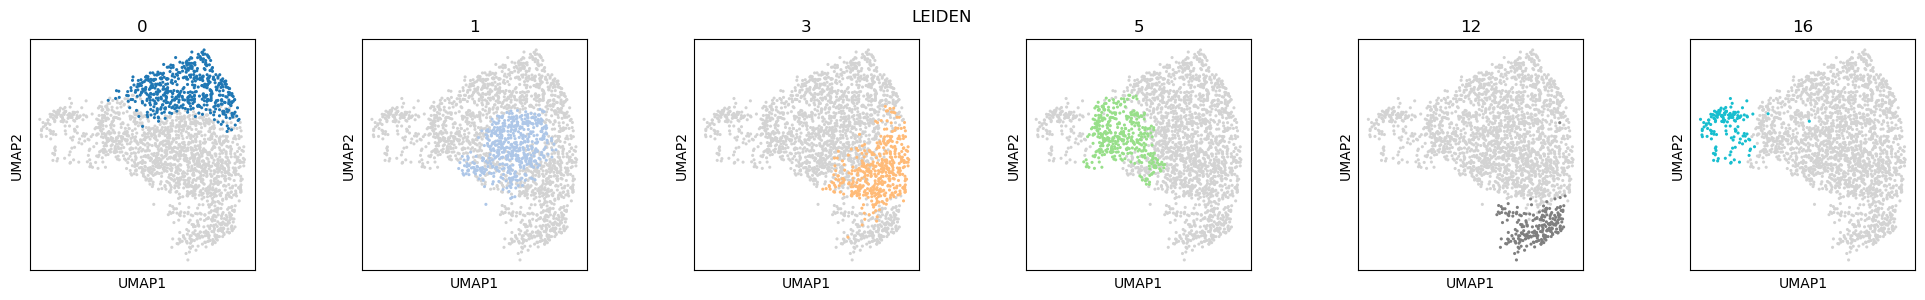

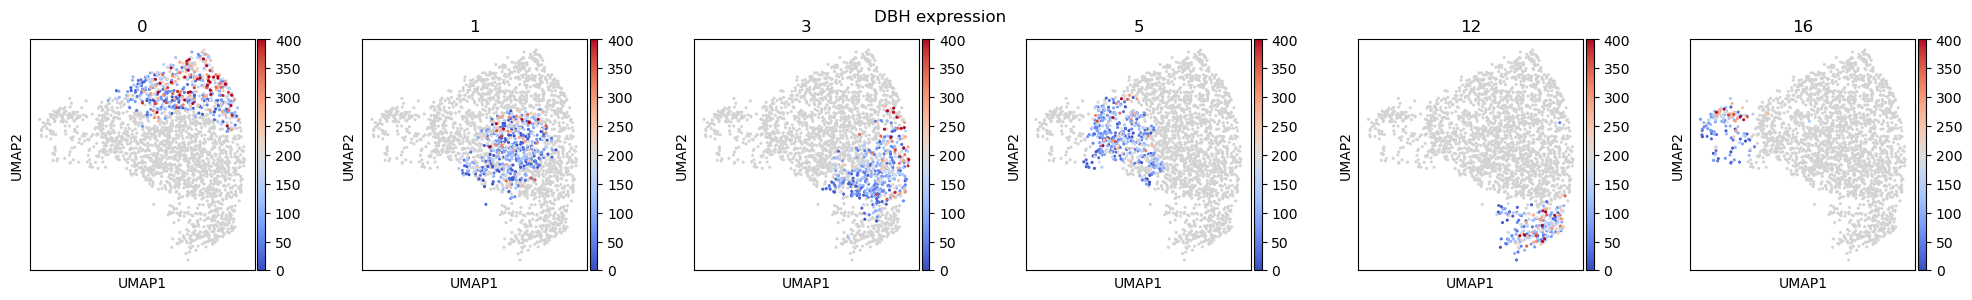

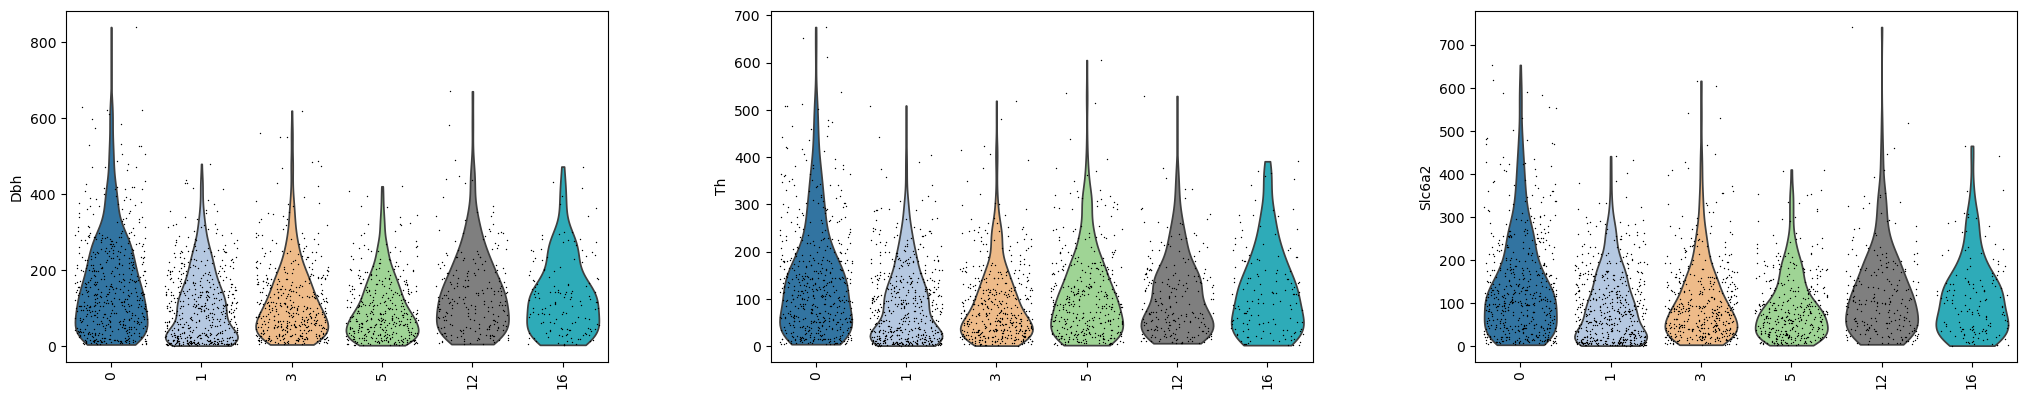

In [43]:

fig, axes = plt.subplots(1,len(chosen_ks),figsize=(25,3),)
for i,k in enumerate(chosen_ks):
    adata_subset = adata_mer[mask].copy() 
    sc.pl.umap(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',
               ax = axes[i],size = 20,alpha = 1,title=str(k), show=False, legend_loc=None,)
    axes[i].set_aspect('equal')
fig.suptitle('LEIDEN')   

fig, axes = plt.subplots(1,len(chosen_ks),figsize=(25,3),)
for i,k in enumerate(chosen_ks):
    adata_subset = adata_mer[mask].copy() 
    sc.pl.umap(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='Dbh',cmap = 'coolwarm',
               vmax = 400,vmin = 0,
               ax = axes[i],size = 20,alpha = 1,title=str(k), show=False, legend_loc=None,)
    axes[i].set_aspect('equal')
fig.suptitle('DBH expression')        
        

sc.pl.violin(
    adata_subset,
    keys=markergenes, groupby="leiden",use_raw=True,
    jitter=0.4,rotation=90, multi_panel=True)        

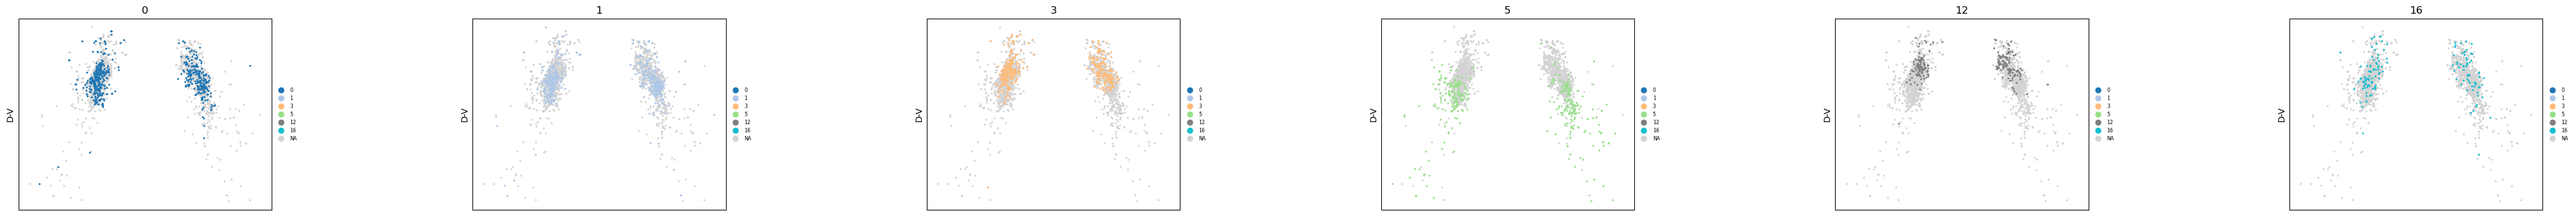

In [44]:
fig, axes = plt.subplots(1,len(chosen_ks),figsize=(55,4))

for i,k in enumerate(chosen_ks):    
    adata_subset = adata_mer[mask].copy() 
    sc.pl.embedding(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',ax = axes[i],
                     dimensions = (2, 1),basis="spatial", size = 20,alpha = 1,
                     title=str(k), show=False, legend_fontsize='xx-small',)
    axes[i].invert_yaxis()
    axes[i].set_aspect('equal')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')

# fig.savefig('./coronal.png', dpi=200)

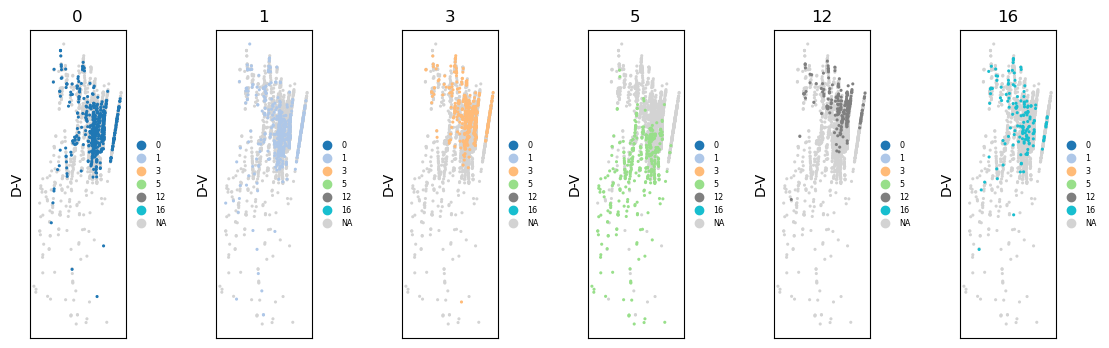

In [45]:
fig, axes = plt.subplots(1,len(chosen_ks),figsize=(14,4))

for i,k in enumerate(chosen_ks):    
    adata_subset = adata_mer[mask].copy() 
    sc.pl.embedding(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',ax = axes[i],
                     dimensions = (0, 1),basis="spatial", size = 20,alpha = 1,
                     title=str(k), show=False, legend_fontsize='xx-small',)
    axes[i].invert_yaxis()
    axes[i].set_aspect('equal')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')

# fig.savefig('./coronal.png', dpi=200)

In [46]:
adata_subset.obs['sex'] = adata_subset.obs['mouse_sex']
adata_subset.shape

(2255, 315)

# save results

In [50]:
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'registered_scratch': PosixPath('/root/capsule/scratch/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [ ]:
adata_subset = adata_mer[mask].copy() 
os.makedirs(paths['result'], exist_ok=True)

filename = os.path.join(paths['result'],'adata_mer_subset_2_2k.h5ad')
adata_subset.write(filename)


### also save the umap results just in case..
(wait is this even necessary if we have the umap saved on our adata?)

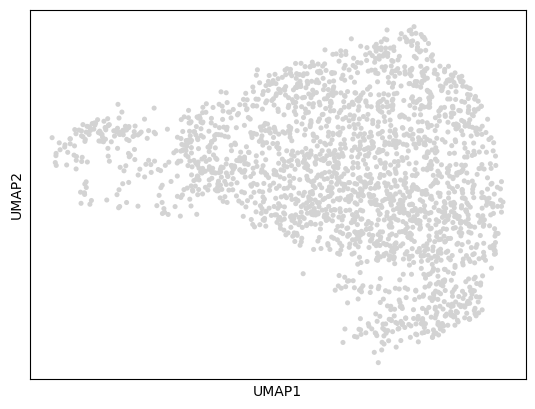

In [52]:
sc.pl.umap(adata_subset)